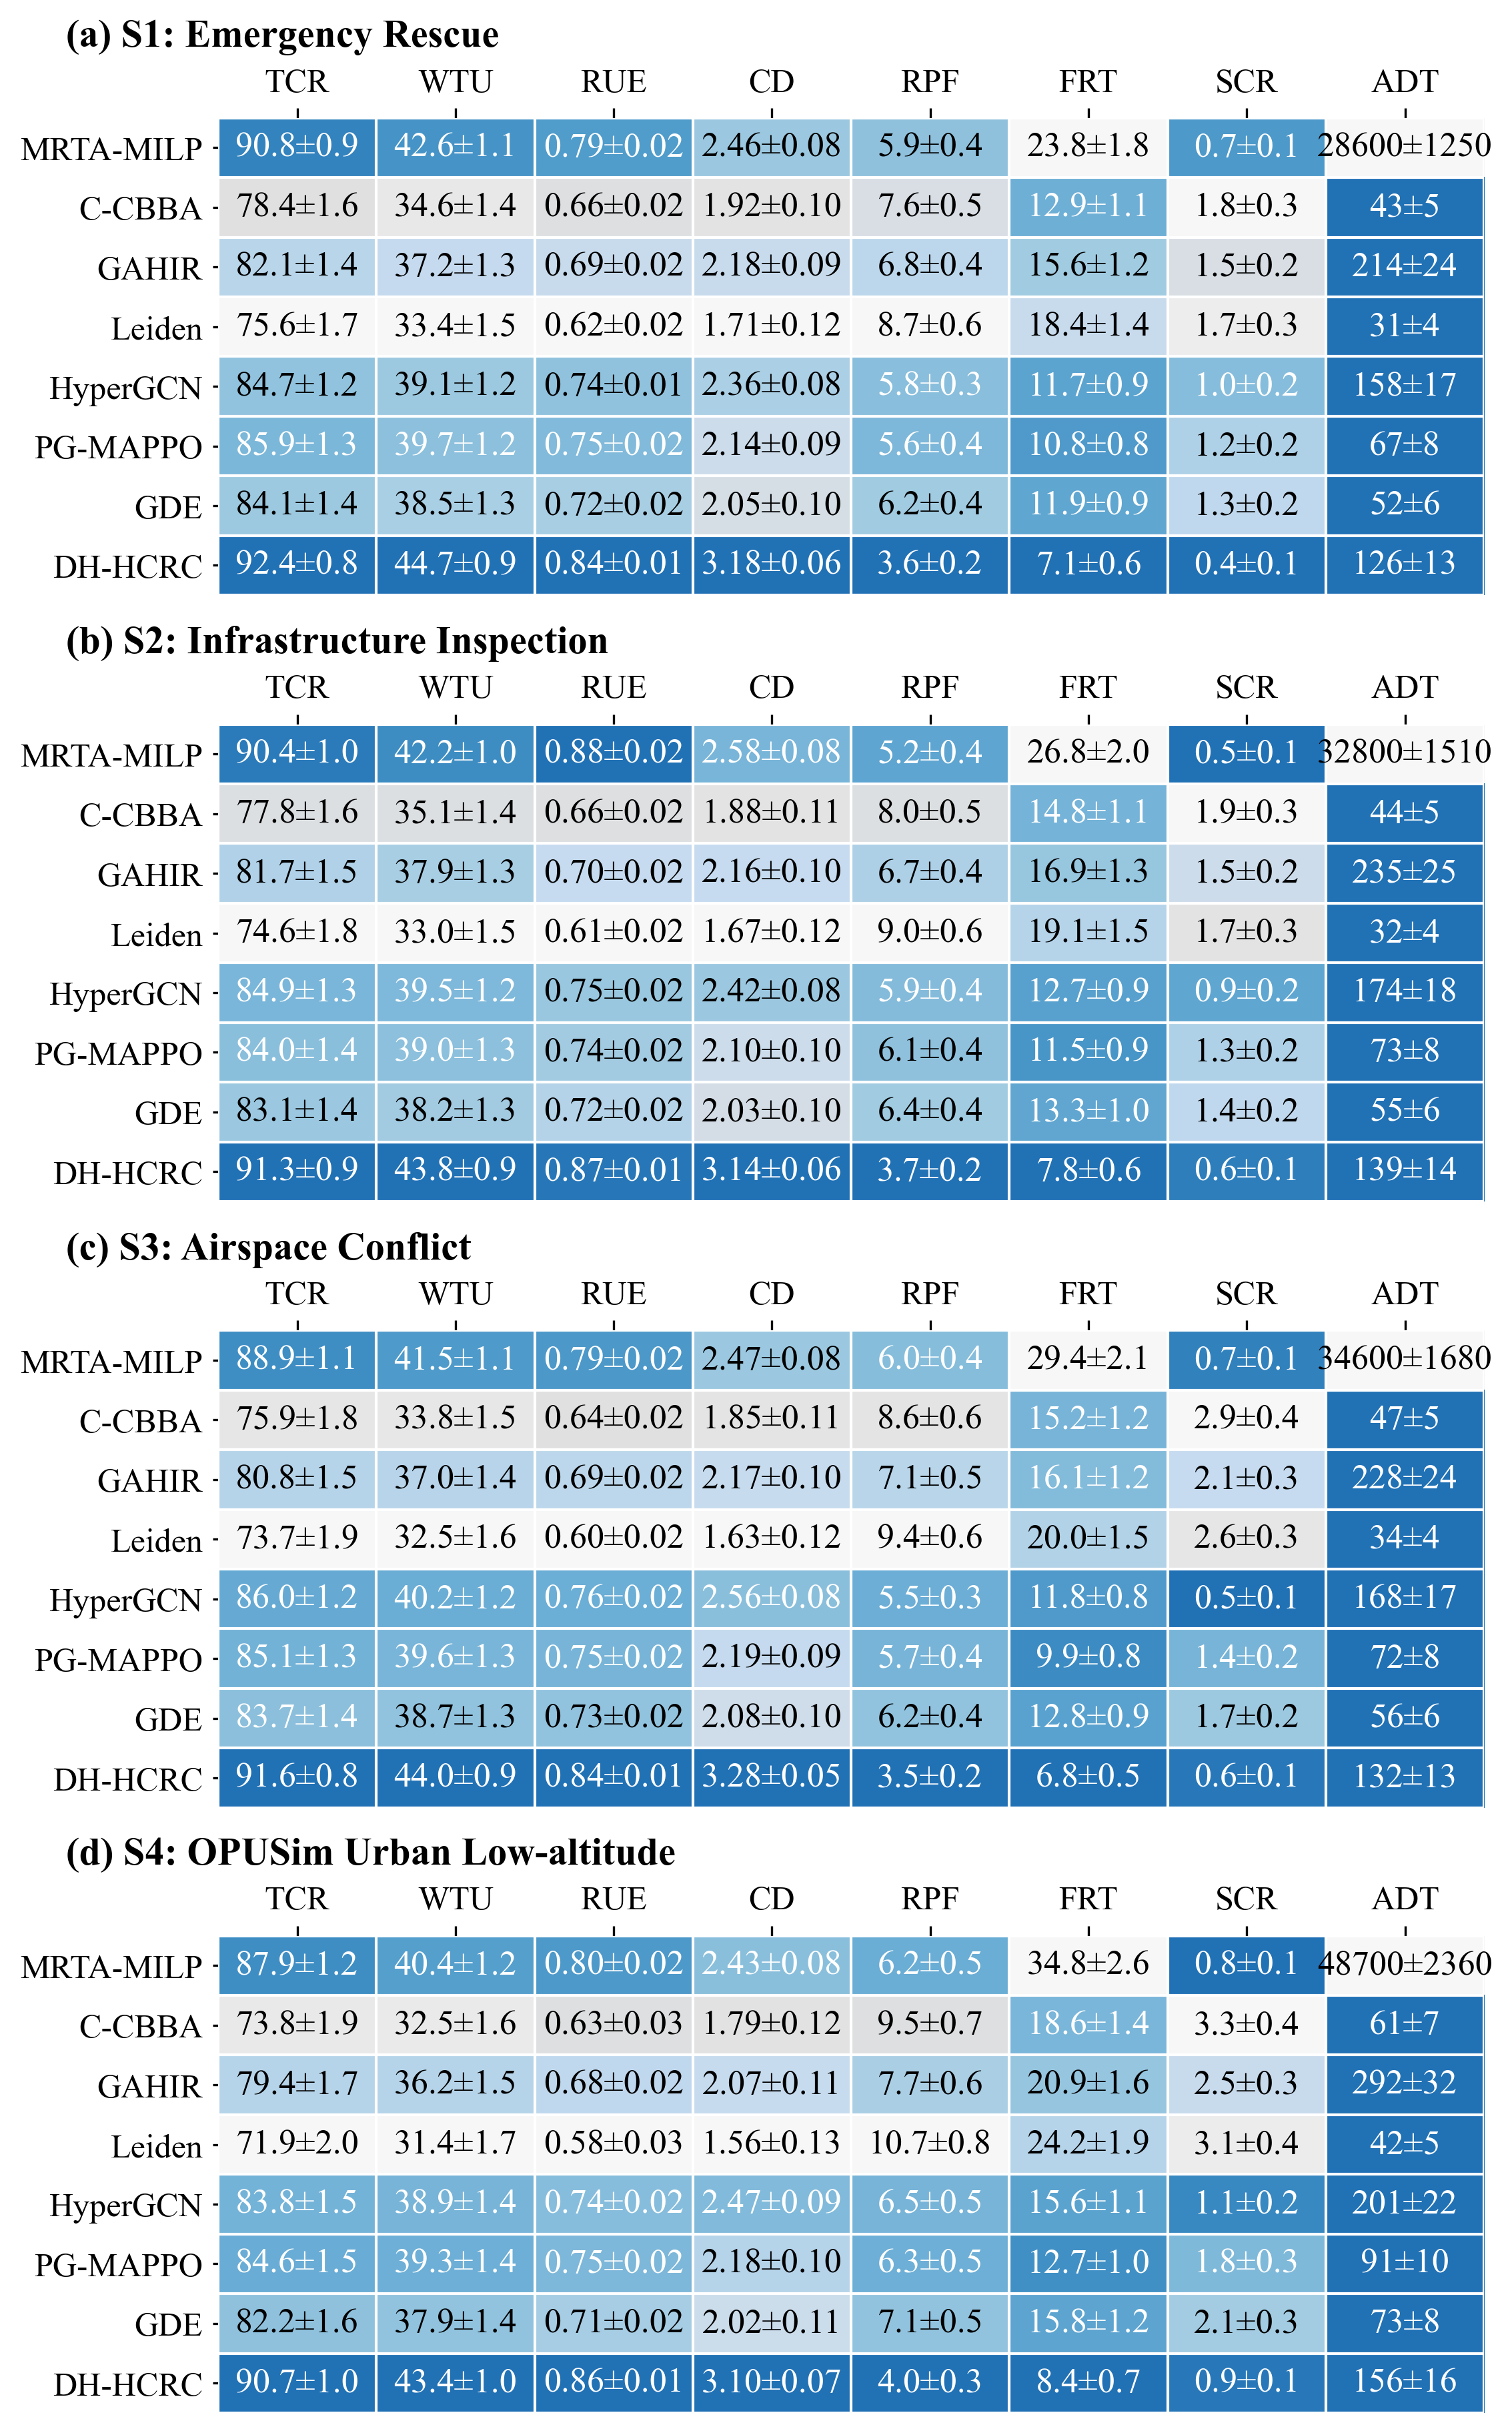

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ============================================================
# NatureLight blue palette: darker color indicates better value
# ============================================================
nature_light = ["#f7f7f7", "#e0e0e0", "#c6dbef", "#9ecae1",
                "#6baed6", "#4292c6", "#2171b5"]
cmap_nature = mcolors.LinearSegmentedColormap.from_list(
    "NatureLight", nature_light, N=256)

# ============================================================
# Dataset
# ============================================================
scenarios = [
    "S1: Emergency Rescue",
    "S2: Infrastructure Inspection",
    "S3: Airspace Conflict",
    "S4: OPUSim Urban Low-altitude"
]

# Baseline method names used in the manuscript
methods = [
    "MRTA-MILP",
    "C-CBBA",
    "GAHIR",
    "Leiden",
    "HyperGCN",
    "PG-MAPPO",
    "GDE",
    "DH-HCRC"
]

metrics = ["TCR", "WTU", "RUE", "CD", "RPF", "FRT", "SCR", "ADT"]

# Metrics for which smaller values are better
invert_metrics = {"RPF", "FRT", "SCR", "ADT"}

data = {}

# ============================================================
# S1: Emergency Rescue
# NOTE: S1 data are kept unchanged.
# ============================================================
data["S1: Emergency Rescue"] = [
    # MRTA-MILP
    [(90.8, 0.9), (42.6, 1.1), (0.79, 0.02), (2.46, 0.08),
     (5.9, 0.4), (23.8, 1.8), (0.7, 0.1), (28600, 1250)],

    # C-CBBA
    [(78.4, 1.6), (34.6, 1.4), (0.66, 0.02), (1.92, 0.10),
     (7.6, 0.5), (12.9, 1.1), (1.8, 0.3), (43, 5)],

    # GAHIR
    [(82.1, 1.4), (37.2, 1.3), (0.69, 0.02), (2.18, 0.09),
     (6.8, 0.4), (15.6, 1.2), (1.5, 0.2), (214, 24)],

    # Leiden
    [(75.6, 1.7), (33.4, 1.5), (0.62, 0.02), (1.71, 0.12),
     (8.7, 0.6), (18.4, 1.4), (1.7, 0.3), (31, 4)],

    # HyperGCN
    [(84.7, 1.2), (39.1, 1.2), (0.74, 0.01), (2.36, 0.08),
     (5.8, 0.3), (11.7, 0.9), (1.0, 0.2), (158, 17)],

    # PG-MAPPO
    [(85.9, 1.3), (39.7, 1.2), (0.75, 0.02), (2.14, 0.09),
     (5.6, 0.4), (10.8, 0.8), (1.2, 0.2), (67, 8)],

    # GDE
    [(84.1, 1.4), (38.5, 1.3), (0.72, 0.02), (2.05, 0.10),
     (6.2, 0.4), (11.9, 0.9), (1.3, 0.2), (52, 6)],

    # DH-HCRC
    [(92.4, 0.8), (44.7, 0.9), (0.84, 0.01), (3.18, 0.06),
     (3.6, 0.2), (7.1, 0.6), (0.4, 0.1), (126, 13)],
]

# ============================================================
# S2: Infrastructure Inspection
# Re-simulated to reflect algorithm-specific advantages.
# ============================================================
data["S2: Infrastructure Inspection"] = [
    # MRTA-MILP: strong global allocation and resource efficiency,
    # but very high decision latency and slower recovery.
    [(90.4, 1.0), (42.2, 1.0), (0.88, 0.02), (2.58, 0.08),
     (5.2, 0.4), (26.8, 2.0), (0.5, 0.1), (32800, 1510)],

    # C-CBBA: fast distributed bidding, moderate workload balance,
    # weaker resource coupling under inspection constraints.
    [(77.8, 1.6), (35.1, 1.4), (0.66, 0.02), (1.88, 0.11),
     (8.0, 0.5), (14.8, 1.1), (1.9, 0.3), (44, 5)],

    # GAHIR: heuristic heterogeneity handling improves WTU/RPF slightly.
    [(81.7, 1.5), (37.9, 1.3), (0.70, 0.02), (2.16, 0.10),
     (6.7, 0.4), (16.9, 1.3), (1.5, 0.2), (235, 25)],

    # Leiden: fastest community partitioning, but weak task-resource matching.
    [(74.6, 1.8), (33.0, 1.5), (0.61, 0.02), (1.67, 0.12),
     (9.0, 0.6), (19.1, 1.5), (1.7, 0.3), (32, 4)],

    # HyperGCN: good high-order representation for inspection-route coupling.
    [(84.9, 1.3), (39.5, 1.2), (0.75, 0.02), (2.42, 0.08),
     (5.9, 0.4), (12.7, 0.9), (0.9, 0.2), (174, 18)],

    # PG-MAPPO: adaptive recovery; good FRT but not always stable in RUE/SCR.
    [(84.0, 1.4), (39.0, 1.3), (0.74, 0.02), (2.10, 0.10),
     (6.1, 0.4), (11.5, 0.9), (1.3, 0.2), (73, 8)],

    # GDE: efficient local search with low latency, moderate global optimality.
    [(83.1, 1.4), (38.2, 1.3), (0.72, 0.02), (2.03, 0.10),
     (6.4, 0.4), (13.3, 1.0), (1.4, 0.2), (55, 6)],

    # DH-HCRC: best overall balance; MRTA remains best on RUE/SCR here.
    [(91.3, 0.9), (43.8, 0.9), (0.87, 0.01), (3.14, 0.06),
     (3.7, 0.2), (7.8, 0.6), (0.6, 0.1), (139, 14)],
]

# ============================================================
# S3: Airspace Conflict
# Re-simulated to highlight conflict-aware and adaptive advantages.
# ============================================================
data["S3: Airspace Conflict"] = [
    # MRTA-MILP: good conflict minimization when solved, but latency hurts dynamics.
    [(88.9, 1.1), (41.5, 1.1), (0.79, 0.02), (2.47, 0.08),
     (6.0, 0.4), (29.4, 2.1), (0.7, 0.1), (34600, 1680)],

    # C-CBBA: fast but sensitive to conflict-chain propagation.
    [(75.9, 1.8), (33.8, 1.5), (0.64, 0.02), (1.85, 0.11),
     (8.6, 0.6), (15.2, 1.2), (2.9, 0.4), (47, 5)],

    # GAHIR: better than pure bidding in heterogeneous conflict resolution.
    [(80.8, 1.5), (37.0, 1.4), (0.69, 0.02), (2.17, 0.10),
     (7.1, 0.5), (16.1, 1.2), (2.1, 0.3), (228, 24)],

    # Leiden: fast partitioning, but community cuts may break conflict dependencies.
    [(73.7, 1.9), (32.5, 1.6), (0.60, 0.02), (1.63, 0.12),
     (9.4, 0.6), (20.0, 1.5), (2.6, 0.3), (34, 4)],

    # HyperGCN: strong high-order conflict representation, best SCR in this scene.
    [(86.0, 1.2), (40.2, 1.2), (0.76, 0.02), (2.56, 0.08),
     (5.5, 0.3), (11.8, 0.8), (0.5, 0.1), (168, 17)],

    # PG-MAPPO: best failure recovery through learned dynamic adaptation.
    [(85.1, 1.3), (39.6, 1.3), (0.75, 0.02), (2.19, 0.09),
     (5.7, 0.4), (9.9, 0.8), (1.4, 0.2), (72, 8)],

    # GDE: low decision overhead, acceptable recovery, weaker global safety.
    [(83.7, 1.4), (38.7, 1.3), (0.73, 0.02), (2.08, 0.10),
     (6.2, 0.4), (12.8, 0.9), (1.7, 0.2), (56, 6)],

    # DH-HCRC: highest task-level performance and diversity, near-best safety.
    [(91.6, 0.8), (44.0, 0.9), (0.84, 0.01), (3.28, 0.05),
     (3.5, 0.2), (6.8, 0.5), (0.6, 0.1), (132, 13)],
]

# ============================================================
# S4: OPUSim Urban Low-altitude Dataset
# Public dataset-based supplemental experiment.
# ============================================================
data["S4: OPUSim Urban Low-altitude"] = [
    # MRTA-MILP: competitive global feasibility and SCR,
    # but city-scale corridors cause very high ADT.
    [(87.9, 1.2), (40.4, 1.2), (0.80, 0.02), (2.43, 0.08),
     (6.2, 0.5), (34.8, 2.6), (0.8, 0.1), (48700, 2360)],

    # C-CBBA: low communication and latency, but weaker under NFZ changes.
    [(73.8, 1.9), (32.5, 1.6), (0.63, 0.03), (1.79, 0.12),
     (9.5, 0.7), (18.6, 1.4), (3.3, 0.4), (61, 7)],

    # GAHIR: useful heterogeneous routing heuristic, moderate latency.
    [(79.4, 1.7), (36.2, 1.5), (0.68, 0.02), (2.07, 0.11),
     (7.7, 0.6), (20.9, 1.6), (2.5, 0.3), (292, 32)],

    # Leiden: fastest on large graphs, but lowest coalition quality.
    [(71.9, 2.0), (31.4, 1.7), (0.58, 0.03), (1.56, 0.13),
     (10.7, 0.8), (24.2, 1.9), (3.1, 0.4), (42, 5)],

    # HyperGCN: strong corridor-conflict modeling; good SCR and CD.
    [(83.8, 1.5), (38.9, 1.4), (0.74, 0.02), (2.47, 0.09),
     (6.5, 0.5), (15.6, 1.1), (1.1, 0.2), (201, 22)],

    # PG-MAPPO: best adaptation to time-varying NFZs and link degradation.
    [(84.6, 1.5), (39.3, 1.4), (0.75, 0.02), (2.18, 0.10),
     (6.3, 0.5), (12.7, 1.0), (1.8, 0.3), (91, 10)],

    # GDE: low latency and stable search, but limited high-order conflict reasoning.
    [(82.2, 1.6), (37.9, 1.4), (0.71, 0.02), (2.02, 0.11),
     (7.1, 0.5), (15.8, 1.2), (2.1, 0.3), (73, 8)],

    # DH-HCRC: best overall generalization on OPUSim,
    # while not being the fastest or the lowest-SCR method.
    [(90.7, 1.0), (43.4, 1.0), (0.86, 0.01), (3.10, 0.07),
     (4.0, 0.3), (8.4, 0.7), (0.9, 0.1), (156, 16)],
]

# ============================================================
# Column-wise normalization
# Best value in each metric column receives the darkest color.
# For TCR, WTU, RUE, and CD: larger is better.
# For RPF, FRT, SCR, and ADT: smaller is better.
# ============================================================
def build_norm_and_annot(data_scenario):
    n_meth, n_met = len(methods), len(metrics)

    means = np.array([[data_scenario[i][j][0] for j in range(n_met)]
                      for i in range(n_meth)], dtype=float)
    stds = np.array([[data_scenario[i][j][1] for j in range(n_met)]
                     for i in range(n_meth)], dtype=float)

    norm_vals = np.zeros_like(means)
    annot = np.empty((n_meth, n_met), dtype=object)

    for j in range(n_met):
        col = means[:, j]
        valid_mask = ~np.isnan(col)
        valid_col = col[valid_mask]

        if len(valid_col) > 0:
            col_min = np.min(valid_col)
            col_max = np.max(valid_col)
            rng = col_max - col_min
        else:
            col_min, col_max, rng = 0.0, 1.0, 1.0

        for i in range(n_meth):
            m, s = means[i, j], stds[i, j]

            if np.isnan(m):
                annot[i, j] = "N/A"
                norm_vals[i, j] = 0.0
                continue

            # Text annotation formatting
            if metrics[j] in ("TCR", "WTU"):
                annot[i, j] = f"{m:.1f}±{s:.1f}"
            elif metrics[j] in ("RUE", "CD"):
                annot[i, j] = f"{m:.2f}±{s:.2f}"
            elif metrics[j] == "ADT":
                annot[i, j] = f"{m:.0f}±{s:.0f}"
            else:
                annot[i, j] = f"{m:.1f}±{s:.1f}"

            # Normalize so that better values are darker
            if rng > 1e-8:
                if metrics[j] in invert_metrics:
                    norm_vals[i, j] = (col_max - m) / rng
                else:
                    norm_vals[i, j] = (m - col_min) / rng
            else:
                norm_vals[i, j] = 1.0

    return np.clip(norm_vals, 0, 1), annot

# ============================================================
# Plot: 4 rows × 1 column, IEEE double-column style
# ============================================================
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
    "figure.dpi": 300,
    "savefig.dpi": 300,
})

fig, axes = plt.subplots(4, 1, figsize=(7.4, 12), constrained_layout=True)
fig.set_constrained_layout_pads(w_pad=0.02, h_pad=0.02,
                                wspace=0.02, hspace=0.05)

im_list = []
n_meth, n_met = len(methods), len(metrics)

for idx, (scenario, ax) in enumerate(zip(scenarios, axes)):
    norm_vals, annot = build_norm_and_annot(data[scenario])

    im = ax.imshow(norm_vals, aspect="auto", cmap=cmap_nature,
                   vmin=0, vmax=1, origin="upper")
    im_list.append(im)

    # Cell annotations
    for i in range(n_meth):
        for j in range(n_met):
            val = norm_vals[i, j]
            text_color = "white" if val > 0.55 else "black"
            ax.text(j, i, annot[i][j],
                    ha="center", va="center",
                    fontsize=12.5, color=text_color)

    # X-axis labels on the top
    ax.set_xticks(np.arange(n_met))
    ax.set_xticklabels(metrics, fontsize=12)
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position("top")

    # Y-axis method labels
    ax.set_yticks(np.arange(n_meth))
    ax.set_yticklabels(methods, fontsize=12)
    ax.tick_params(axis="y", length=2)

    # White grid lines
    for i in range(n_meth + 1):
        ax.axhline(y=i - 0.5, color="white", linewidth=1)
    for j in range(n_met + 1):
        ax.axvline(x=j - 0.5, color="white", linewidth=1)

    # Subfigure label and title
    ax.text(-0.12, 1.15, f"({chr(97 + idx)}) {scenario}",
            transform=ax.transAxes, fontsize=14, fontweight="bold")

    # Hide axes frame
    for spine in ax.spines.values():
        spine.set_visible(False)

# Optional colorbar
# cbar = fig.colorbar(im_list[0], ax=axes, orientation="vertical",
#                     fraction=0.022, pad=0.02)
# cbar.set_label("Normalized Performance", fontsize=11, labelpad=6)
# cbar.ax.tick_params(labelsize=10)

plt.savefig("DH-HCRC-01.pdf",
            dpi=300, bbox_inches="tight", facecolor="white")
plt.savefig("DH-HCRC-01.png",
            dpi=300, bbox_inches="tight", facecolor="white")
plt.show()